In [1]:
import torch
import torch.nn as nn
import torch_geometric.data as pygd
import networkx as nx
import matplotlib.pyplot as plt

from gnn.data import prepare_fact_batch
from hakken_ml_toolkit.ml_utils.extras import NetworkXUtils, FactBatchUtils, TensorCreator
from hakken_ml_toolkit.ml_utils.constants import ActivationType
from gnn.common.constants import StageType
from gnn import GCN, GCNConfig

# Define utility functions for visualization

In [2]:
def plot(G: nx.Graph):
    """
    Plot a NetworkX graph with different edge colors/styles.
    
    Args:
        G: A NetworkX graph or multi-digraph
    """
    # Plot with different edge colors/styles
    pos = nx.spring_layout(G)
    nx.draw_networkx_nodes(G, pos)
    nx.draw_networkx_labels(G, pos)

    # Draw edges with different colors for parallel edges
    colors = ['r', 'b', 'g', 'purple']
    for i, (u, v, k) in enumerate(G.edges(keys=True)):
        nx.draw_networkx_edges(G, pos, 
                                edgelist=[(u,v)],
                                edge_color=colors[k],
                                connectionstyle=f'arc3, rad={0.1*(i+1)}',
                                arrows=True)

    plt.title('MultiDiGraph with Parallel Edges')
    plt.axis('off')
    plt.show()

# Data Processing and analysis


In [3]:
# Create a sample knowledge graph as fact batch
# Each row represents a fact with [subject_id, relation_id, object_id]
fact_batch = TensorCreator.long_tensor([
    [0, 0, 1], 
    [0, 1, 1], 
    [1, 1, 2], 
    [3, 1, 2], 
    [3, 1, 4], 
    [4, 0, 1]
])

Number of edges: 6
Number of nodes: 5


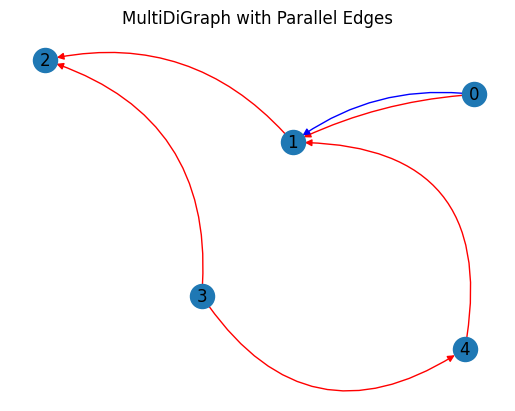

In [4]:
multi_digraph = FactBatchUtils.to_networkx(fact_batch)

print(f"Number of edges: {multi_digraph.number_of_edges()}")
print(f"Number of nodes: {multi_digraph.number_of_nodes()}")

plot(multi_digraph)

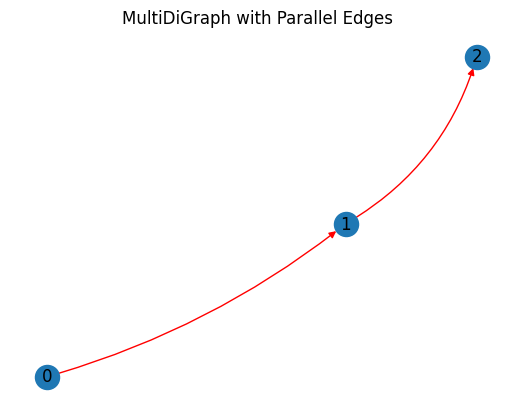

In [5]:
# Generate a random walk subgraph from the knowledge graph
# This can be useful for sampling or exploring graph neighborhoods
subgraph = NetworkXUtils.get_random_walks_subgraph(
    multi_digraph, 
    start_node=0,     
    num_walks=1,       
    walk_length=2,     
    seed=2      
)

plot(subgraph)

In [6]:
# Prepare data for GNN processing and initialize node embeddings
# Convert the fact batch to PyTorch Geometric Data format
embedding_dim = 16
data = prepare_fact_batch(fact_batch)

# Initialize random node embeddings
node_embeddings = torch.randn((data.num_nodes, embedding_dim))
data.x = node_embeddings

# Initialize random edge/relation embeddings (not used in this basic demo)
edge_embeddings = torch.randn((data.num_relations, embedding_dim))

print(data)

Data(edge_index=[2, 6], edge_type=[6], num_nodes=5, num_relations=2, x=[5, 16])


# Build the GCN model

In [7]:
# Create a configuration for the Graph Convolutional Network
config = GCNConfig(
    input_dim=embedding_dim,        # Dimension of input node features
    output_dim=1,                   # Dimension of output predictions
    hidden_dim=32,                  # Dimension of hidden layers
    activation=ActivationType.RELU, # Activation function
    dropout=0.0,                    # Dropout probability
    batch_norm=False,               # Whether to use batch normalization
    stage_type=StageType.SKIPSUM,   # Type of skip connections
    num_layers_pre=1,               # Number of pre-processing layers
    num_layers_gnn=1,               # Number of GNN layers
    num_layers_post=1,              # Number of post-processing layers
    pooling=None,                   # Pooling strategy (None = no pooling)
    device="cpu"                    # Device to run the model on
)

In [8]:
# Create GCN model with the specified configuration
model = GCN(config)
print(f"Model architecture:\n{model}")

# Forward pass through the model
logits = model(data)
print(f"\nOutput shape: {logits.shape}")

# For demonstration, if we want to interpret this as a binary classification task
probabilities = torch.sigmoid(logits)
print(f"\nPrediction probabilities:\n{probabilities}")

Model architecture:
GCN(
  (pre_nn): MLP(
    (fc_layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=16, out_features=32, bias=True)
        (1): ReLU()
      )
    )
  )
  (lin_skipsum): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=32, out_features=32, bias=True)
    )
  )
  (gnn): ModuleList(
    (0): Sequential(
      (0): MyGCNConv(32, 32)
      (1): NodeWrapper(
        (layer): ReLU()
      )
    )
  )
  (post_nn): MLP(
    (fc_layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=32, out_features=1, bias=True)
        (1): Identity()
      )
    )
  )
)

Output shape: torch.Size([5, 1])

Prediction probabilities:
tensor([[0.5334],
        [0.5104],
        [0.4444],
        [0.4918],
        [0.5692]], grad_fn=<SigmoidBackward0>)


# Training loop example

In [11]:
# Initialize optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()  # Binary cross entropy loss with logits

# Create dummy target values for demonstration
# In a real scenario, these would be your ground truth labels
targets = torch.randint(0, 2, (data.num_nodes, 1)).float()

# Sample training iteration
def train_iteration(
    model: torch.nn.Module,
    data: pygd.Data,
    targets: torch.Tensor,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module
) -> float:
    # Set model to training mode
    model.train()
    
    # Zero gradients
    optimizer.zero_grad()
    
    # Forward pass
    logits = model(data)
    
    # Compute loss
    loss: torch.Tensor = loss_fn(logits, targets)
    
    # Backward pass
    loss.backward()
    
    # Update weights
    optimizer.step()
    
    return loss.item()
# Demonstrate single training iteration
for epoch in range(10):
    loss = train_iteration(model, data, targets, optimizer, loss_fn)
    print(f"Training loss: {loss:.4f}")

Training loss: 0.6962
Training loss: 0.4749
Training loss: 0.3346
Training loss: 0.2441
Training loss: 0.1825
Training loss: 0.1321
Training loss: 0.0892
Training loss: 0.0549
Training loss: 0.0319
Training loss: 0.0181


# Inference example

Node 0: Probability = 0.9706, Prediction = 1
Node 1: Probability = 0.0191, Prediction = 0
Node 2: Probability = 0.0000, Prediction = 0
Node 3: Probability = 0.0004, Prediction = 0
Node 4: Probability = 0.0006, Prediction = 0


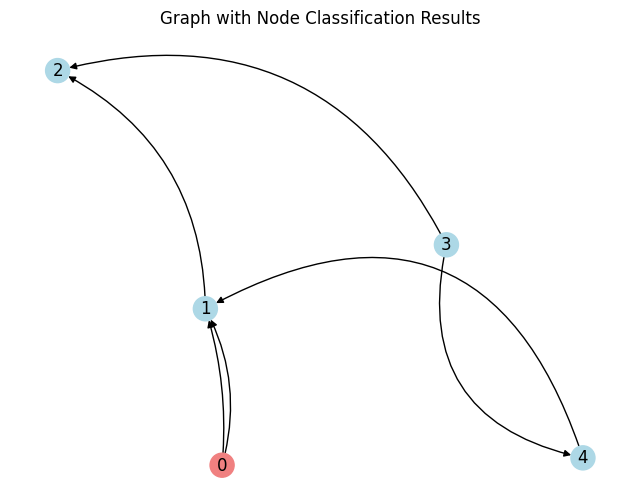

In [12]:
# Set model to evaluation mode
model.eval()

# Perform inference
with torch.no_grad():
    logits = model(data)
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > 0.5).float()

# Display results for each node
for node_idx in range(data.num_nodes):
    print(f"Node {node_idx}: Probability = {probabilities[node_idx].item():.4f}, Prediction = {predictions[node_idx].item():.0f}")

# Visualize prediction results on the graph
# Create a colormap based on predictions
node_colors = ['lightblue' if pred.item() < 0.5 else 'lightcoral' for pred in predictions]

# Plot the graph with node colors representing predictions
pos = nx.spring_layout(multi_digraph)
plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(multi_digraph, pos, node_color=node_colors)
nx.draw_networkx_labels(multi_digraph, pos)

# Draw edges
for i, (u, v, k) in enumerate(multi_digraph.edges(keys=True)):
    nx.draw_networkx_edges(multi_digraph, pos, 
                           edgelist=[(u,v)],
                           connectionstyle=f'arc3, rad={0.1*(i+1)}',
                           arrows=True)

plt.title('Graph with Node Classification Results')
plt.axis('off')
plt.show()